<a href="https://colab.research.google.com/github/gawatemotiram15-del/Ecommerce--Customer-Intelligence-recomnedtation/blob/main/Product_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Emme-Corce Product Recommendation System

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import os

print("Files available in Colab:")
for file in os.listdir():
    print(file)

Files available in Colab:
.config
sample_data


In [ ]:
from google.colab import files

uploaded = files.upload()

print("Files uploaded:")
for filename in uploaded.keys():
    print(filename)

Saving olist_orders_dataset.csv to olist_orders_dataset.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Files uploaded:
olist_orders_dataset.csv
olist_products_dataset.csv
olist_order_items_dataset.csv


In [ ]:
import pandas as pd

orders = pd.read_csv("olist_orders_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")

print("Orders:", orders.shape)
print("Products:", products.shape)
print("Order Items:", order_items.shape)

Orders: (99441, 8)
Products: (32951, 9)
Order Items: (112650, 7)


In [ ]:
# Merge order items with product information
recommendation_data = order_items.merge(
    products,
    on="product_id",
    how="left"
)

print("Recommendation Data Shape:", recommendation_data.shape)
print(recommendation_data[["order_id", "product_id", "product_category_name"]].head())

Recommendation Data Shape: (112650, 15)
                           order_id                        product_id  \
0  00010242fe8c5a6d1ba2dd792cb16214  4244733e06e7ecb4970a6e2683c13e61   
1  00018f77f2f0320c557190d7a144bdd3  e5f2d52b802189ee658865ca93d83a8f   
2  000229ec398224ef6ca0657da4fc703e  c777355d18b72b67abbeef9df44fd0fd   
3  00024acbcdf0a6daa1e931b038114c75  7634da152a4610f1595efa32f14722fc   
4  00042b26cf59d7ce69dfabb4e55b4fd9  ac6c3623068f30de03045865e4e10089   

  product_category_name  
0            cool_stuff  
1              pet_shop  
2      moveis_decoracao  
3            perfumaria  
4    ferramentas_jardim  


In [ ]:
top_products = recommendation_data["product_id"].value_counts().head(10)

print("Top 10 Recommended Products:")
print(top_products)

Top 10 Recommended Products:
product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
Name: count, dtype: int64


In [ ]:
top_products = (
    recommendation_data.groupby(
        ["product_id", "product_category_name"]
    )
    .size()
    .reset_index(name="purchase_count")
    .sort_values("purchase_count", ascending=False)
    .head(10)
)

print("Top 10 Recommended Products:")
print(top_products)

Top 10 Recommended Products:
                             product_id   product_category_name  \
21724  aca2eb7d00ea1a7b8ebd4e68314663af        moveis_decoracao   
19394  99a4788cb24856965c36a24e339b6058         cama_mesa_banho   
8456   422879e10f46682990de24d770e7f83d      ferramentas_jardim   
7231   389d119b48cf3043d311335e499d9c6b      ferramentas_jardim   
6950   368c6c730842d78016ad823897a372db      ferramentas_jardim   
10638  53759a2ecddad2bb87a079a1f1519f73      ferramentas_jardim   
26545  d1c427060a0f73f6b889a5c7c61f2ac4  informatica_acessorios   
10665  53b36df67ebb7c41585e8d54d6772e08      relogios_presentes   
2743   154e7e31ebfa092203795c972e5804a6            beleza_saude   
7905   3dd2a17168ec895c781a9191c1e95ad7  informatica_acessorios   

       purchase_count  
21724             527  
19394             488  
8456              484  
7231              392  
6950              388  
10638             373  
26545             343  
10665             323  
2743             

In [ ]:
def recommend_products(category, n=5):
    recommendations = (
        recommendation_data[
            recommendation_data["product_category_name"] == category
        ]
        .groupby(["product_id", "product_category_name"])
        .size()
        .reset_index(name="purchase_count")
        .sort_values("purchase_count", ascending=False)
        .head(n)
    )

    return recommendations


# Example recommendation
recommend_products("ferramentas_jardim", 5)

,product_id,product_category_name,purchase_count
211,422879e10f46682990de24d770e7f83d,ferramentas_jardim,484
180,389d119b48cf3043d311335e499d9c6b,ferramentas_jardim,392
168,368c6c730842d78016ad823897a372db,ferramentas_jardim,388
273,53759a2ecddad2bb87a079a1f1519f73,ferramentas_jardim,373
582,c4baedd846ed09b85f78a781b522f126,ferramentas_jardim,149


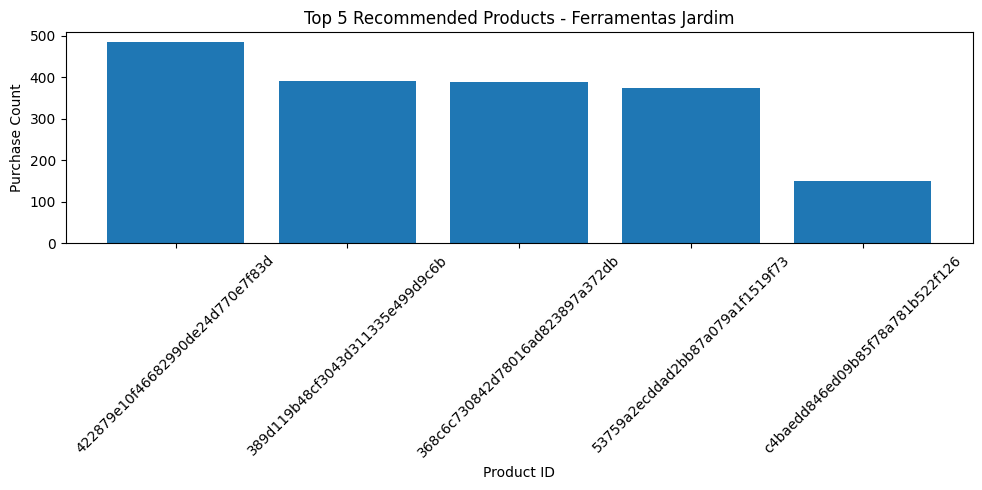

In [ ]:
import matplotlib.pyplot as plt

recommendations = recommend_products("ferramentas_jardim", 5)

plt.figure(figsize=(10, 5))
plt.bar(
    recommendations["product_id"].astype(str),
    recommendations["purchase_count"]
)

plt.xlabel("Product ID")
plt.ylabel("Purchase Count")
plt.title("Top 5 Recommended Products - Ferramentas Jardim")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The Product Recommendation System successfully recommends the top 5 products from the selected product category based on purchase frequency. The visualization shows the most frequently purchased products in the ferramentas_jardim category.